위치 인코딩 계산 과정

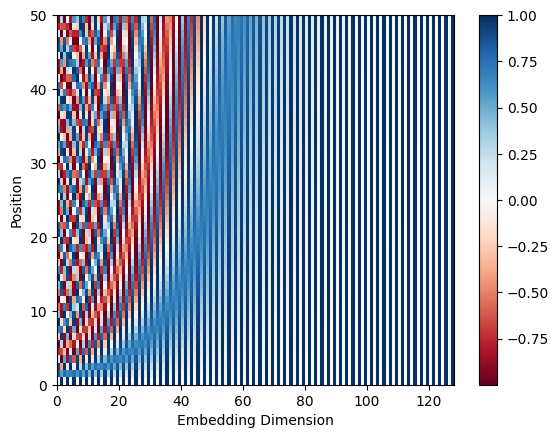

In [ ]:
import math
import torch
from torch import nn
from matplotlib import pyplot as plt

class PositionalEncoding(nn.Module):
  def __init__(self, d_model, max_len, dropout=0.1):
    super().__init__()
    self.dropout = nn.Dropout(p=dropout)

    position = torch.arange(max_len).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
    )
    pe = torch.zeros(max_len, 1, d_model)
    pe[:, 0, 0::2] = torch.sin(position * div_term)
    pe[:, 0, 1::2] = torch.cos(position * div_term)
    self.register_buffer("pe", pe)

  def forward(self, x):
    x = x+ self.pe[: x.size(0)]
    return self.dropout(x)

encoding = PositionalEncoding(d_model=128, max_len=50)

plt.pcolormesh(encoding.pe.numpy().squeeze(), cmap="RdBu")
plt.xlabel("Embedding Dimension")
plt.xlim((0, 128))
plt.ylabel("Position")
plt.colorbar()
plt.show()

##실습
파이토치에서 제공하는 트랜스포머 모델을 활용해 영어-독일어 번역 모델 구성
Multi30k 데이터셋 사용: 대규모 다국어 데이터셋
- Multi30k dataset은 영어-독일어 병렬 말뭉치로 약30000개의 데이터 제공
- 토치 데이터와 토치 텍스트 라이브러리로 해당 데이터셋 다운로드 가능
- portalocker 라이브러리: 파이썬에서 파일 락을 관리하기 위한 라이브러리. 파일 락을 시영해 여러 프로세스 간에 동시에 파일을 읽거나 수정하는것 방지.

### 라이브러리 재설치 (런타임 재시작 후 실행)

In [ ]:
# 런타임을 재시작한 후, 아래 명령어를 실행하여 호환되는 라이브러리 버전을 강제로 재설치합니다.
# `--force-reinstall` 플래그는 기존 설치된 패키지를 제거하고 다시 설치합니다.
!pip install --force-reinstall torch==2.2.2 torchtext==0.17.2 torchdata==0.7.1 portalocker

# 설치가 완료되면, 다음 셀에서 다시 버전을 확인해 보세요.
# 이 셀을 실행한 후에는 kernel이 재시작되므로, 이전에 실행했던 import 문 등은 다시 실행해야 합니다.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.4/184.4 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

In [1]:
import torch
import torchdata
import torchtext

print(torch.__version__)
print(torchdata.__version__)
print(torchtext.__version__)

2.2.2+cu121
0.7.1
0.17.2+cpu


In [ ]:
!python -m spacy download de_core_news_sm
!python -m spacy download en_core_web_sm


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 189, in _run_module_as_main
  File "<frozen runpy>", line 148, in _get_module_details
  File "<frozen runpy>", line 112, in _get_module_details
  File "/usr/local/lib/python3.12/dist-packages/spacy/__init__.py", line 6, in <module>
    from .errors import setup_default_warnings
  File "/usr/local/lib/python3.12/dist-packages/spacy/errors.py", line 3, in <module>
    from .compat import Literal
  File "/usr/local/lib/python3.12/dist-packages/spacy/compat.py", line 5, in <module>
    from thinc.

In [ ]:
#install torchdata, torchtext library
!pip install torchdata torchtext portalocker

데이터셋 다운로드 및 전처리
- 독일어 말뭉치 (de_core_news_sm)와 영어 말뭉치(en_core_web_sm)에 대해 각각 토크나이저와 어휘사전을 생성
- get_tokenizer함수는 사용자가 지정한 토크나이저를 가져오는 유틸리티 함수로 spacy라이브러리로 사전학습된 모델을 가져온다. 이 값을 token_transform변수에 저장
- vocab_transform변수는 토큰을 인텍스로 변환시키는 함수 저장
-build_vocab_from_iterator: 생성된 토큰을 이용해 단어 집합 생성
- set_default_index: 인덱스의 기본값을 설정, 어휘 사전에 없는 토큰인 <unk>의 인덱스 할당

In [2]:
from torchtext.datasets import Multi30k
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator

def generate_tokens(text_iter, language):
  language_index = {SRC_LANGUAGE: 0, TGT_LANGUAGE: 1}

  for text in text_iter:
    yield token_transform[language](text[language_index[language]])


SRC_LANGUAGE="de"
TGT_LANGUAGE="en"
UNK_IDX, PAD_IDX, BOS_IDX, EOS_IDX = 0, 1, 2, 3
special_symbols = ["<unk>", "<pad>", "<bos>", "<eos>"]

token_transform = {
    SRC_LANGUAGE: get_tokenizer("spacy", language="de_core_news_sm"),
    TGT_LANGUAGE: get_tokenizer("spacy", language="en_core_web_sm"),
}
print("Token Transform: ")
print(token_transform)

vocab_transform={}
for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
  train_iter = Multi30k(split="train", language_pair=(SRC_LANGUAGE, TGT_LANGUAGE))
  vocab_transform[language] = build_vocab_from_iterator(
      generate_tokens(train_iter, language),
      min_freq=1,
      specials=special_symbols,
      special_first=True,
  )

for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
  vocab_transform[language].set_default_index(UNK_IDX)

print("Vocab Tranform: ")
print(vocab_transform)

Token Transform: 
{'de': functools.partial(<function _spacy_tokenize at 0x7e433b334cc0>, spacy=<spacy.lang.de.German object at 0x7e433697f320>), 'en': functools.partial(<function _spacy_tokenize at 0x7e433b334cc0>, spacy=<spacy.lang.en.English object at 0x7e433694cc80>)}
Vocab Tranform: 
{'de': Vocab(), 'en': Vocab()}


트랜스포머 모델 구축

In [3]:
import math
import torch
from torch import nn


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0)]
        return self.dropout(x)


class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, emb_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_size)
        self.emb_size = emb_size

    def forward(self, tokens):
        return self.embedding(tokens.long()) * math.sqrt(self.emb_size)


class Seq2SeqTransformer(nn.Module):
    def __init__(
        self,
        num_encoder_layers,
        num_decoder_layers,
        emb_size,
        max_len,
        nhead,
        src_vocab_size,
        tgt_vocab_size,
        dim_feedforward=512,
        dropout=0.1,
    ):

        super().__init__()
        self.src_tok_emb = TokenEmbedding(src_vocab_size, emb_size)
        self.tgt_tok_emb = TokenEmbedding(tgt_vocab_size, emb_size)
        self.positional_encoding = PositionalEncoding(
            d_model=emb_size, max_len=max_len, dropout=dropout,
        )

        self.transformer = nn.Transformer(
            d_model=emb_size,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
        )
        self.generator = nn.Linear(emb_size, tgt_vocab_size)

    def forward(
        self,
        src,
        trg,
        src_mask,
        tgt_mask,
        src_padding_mask,
        tgt_padding_mask,
        memory_key_padding_mask,
    ):

        src_emb = self.positional_encoding(self.src_tok_emb(src))
        tgt_emb = self.positional_encoding(self.tgt_tok_emb(trg))
        outs = self.transformer(
            src=src_emb,
            tgt=tgt_emb,
            src_mask=src_mask,
            tgt_mask=tgt_mask,
            memory_mask=None,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask,
        )

        return self.generator(outs)

    def encode(self, src, src_mask):
        return self.transformer.encoder(
            self.positional_encoding( self.src_tok_emb(src)), src_mask,
        )

    def decode(self, tgt, memory, tgt_mask):

        return self.transformer.decoder(
            self.positional_encoding( self.tgt_tok_emb(tgt)), memory, tgt_mask)

트랜스포머 클래스
- d_model:트랜스포머 모델의 입력과 출력 차원의 크기 정의, 임베딩 차원 크기와 동일
- nhead : 멀티 헤드 어텐션의 헤드의 갯수 정의-> 모델이 어텐션을 수행하는 방법 결정. 헤드의 갯수는 모델의 병렬처리 능력, 매개변수의 수와과 비례
- num_encoder_layers, num_decoder_layers: 인코더와 디코더의 계층 수, 모델의 복잡도와 성능에 영향
- dim_feedforward: 순방향 신경망의 은닉층 크기 정의. 모델의 복잡도돠 성능에 영향
- dropout: 인코더와 디코더 계층에 적용되는 드롭아웃 비용 적용
- activation: 순방향 신경망에 적용되는 활성화 함수 의미
- layer_norm_eps: 계층 정규화를 수행할 때 분모데 더해지는 입실론 값 정의


In [4]:
transformer = torch.nn.Transformer(
    d_model=512,
    nhead=8,
    num_encoder_layers=6,
    num_decoder_layers=6,
    dim_feedforward=2048,
    dropout=0.1,
    activation=torch.nn.functional.relu,
    layer_norm_eps=1e-05,
)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


트랜스포머 순방향 메서드
- src(source), tgt(target):인코더와 디코더에 대한 시퀀스, [소스 시퀀스 길이, 배치 크기, 임베딩 차원], [타겟 시퀀스 길이, 배치 크기, 임베딩 차원] 형태의 데이터를 입력받음
- src_mask, tgt_mask: 소스와 타깃 시퀀스의 마스크, [소스 시퀀스 길이, 시퀀스 길이 ], [타겟 시퀀스 길이, 시퀀스 길이 ] 형태의 데이터를 입력받음
  - 마스크 값 = 0: 해당 위치에서는 모든 입력 단어가 동일한 가중치
  - 마스크 값 = 1: 모든 입력 단어의 가중치=0-> 어텍션 연산x
  - 마스크 값 = -inf: 어텐션 연산 결과에 0으로 가중치가 부여돼 마스킹된 위치의 정보를 모델이 무시
  - 마스크 값 = +inf : 모든 입력 단어에 무한대의 가중치가 부여돼 어텐션 연산 결과가 해당 위치에 대한 정보만으로 구성  
- memory_mask: 인코더 출력의 마스크, [타깃 시퀀스 길이, 소스 시퀀스 길이] 형태. 메모리 마스크 값이 0인 위치에서는 어텐션 연산이 수행되지 않는다.
- key_ladding_mask: 소스 타깃, 메모리 시퀀스에 대한 패딩 마스크. [배치 크기, 소스(타깃) 시퀀스 길이 ] 형태의 데이터 입력 받음. 메모리 키 패딩 마스크는 소스 키 패딩 마스크와 동이한 형태의 데이터 입력

In [ ]:
output = transformer.forward(
    src,
    tgt,
    src_mask=None,
    tgt_mask=None,
    memory_mask=None,
    src_key_padding_mask=None,
    tgt_key_padding_mask=None,
    memory_key_padding_mask=None,
)

NameError: name 'src' is not defined

트랜스포머 모델 선언 및 구조

In [5]:
from torch import optim

BATCH_SIZE=128
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = Seq2SeqTransformer(
    num_encoder_layers=3,
    num_decoder_layers=3,
    emb_size=512,
    max_len=512,
    nhead=8,
    src_vocab_size=len(vocab_transform[SRC_LANGUAGE]),
    tgt_vocab_size=len(vocab_transform[TGT_LANGUAGE]),
    dim_feedforward=512,
).to(DEVICE)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX).to(DEVICE)
optimizer = optim.Adam(model.parameters())

for main_name, main_module in model.named_children():
    print(main_name)

    for sub_name, sub_module in main_module.named_children():
        print("|-", sub_name)

        for ssub_name, ssub_module in sub_module.named_children():
            print("|  |- ", ssub_name)

            for sssub_name, sssub_module in ssub_module.named_children():
                print("|  |  |- ", sssub_name)

src_tok_emb
|- embedding
tgt_tok_emb
|- embedding
positional_encoding
|- dropout
transformer
|- encoder
|  |-  layers
|  |  |-  0
|  |  |-  1
|  |  |-  2
|  |-  norm
|- decoder
|  |-  layers
|  |  |-  0
|  |  |-  1
|  |  |-  2
|  |-  norm
generator


배치 데이터 생성

*   token_transform: 문장 토큰화
*   vocab_transform: 토큰 인덱스화
* input_transform: 인덱스화된 토큰에 문장의 시작과 끝을 알리는 특수 토큰 할당
* collator: 배치 단위로 데이터 처리
* pad_sequence: 소스&타깃 시퀀스 패딩. 동일한 길이를 가지도록 시퀀스의 뒤쪽에 PAD_IDX로 채워진 패딩 토큰 추가



In [6]:
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

def sequential_transforms(*transforms):
  def func(txt_input):
    for transform in transforms:
      txt_input=transform(txt_input)
    return txt_input
  return func

def input_transform(token_ids):
  return torch.cat(
      (torch.tensor([BOS_IDX]), torch.tensor(token_ids), torch.tensor([EOS_IDX]))
  )

def collator(batch):
  src_batch, tgt_batch = [], []
  for src_sample, tgt_sample in batch:
    src_batch.append(text_transform[SRC_LANGUAGE](src_sample.rstrip("\n")))
    tgt_batch.append(text_transform[TGT_LANGUAGE](tgt_sample.rstrip("\n")))

  src_batch = pad_sequence(src_batch, padding_value=PAD_IDX)
  tgt_batch = pad_sequence(tgt_batch, padding_value=PAD_IDX)
  return src_batch, tgt_batch

text_transform = {}
for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
  text_transform[language] = sequential_transforms(
      token_transform[language], vocab_transform[language], input_transform
  )

data_iter = Multi30k(split="valid", language_pair=(SRC_LANGUAGE, TGT_LANGUAGE))
dataloader = DataLoader(data_iter, batch_size=BATCH_SIZE, collate_fn=collator)
source_tnesor, target_tensor = next(iter(dataloader))

print("(source target): ")
print(next(iter(data_iter)))

print("source_batch:", source_tnesor.shape)
print(source_tnesor)

print("target_batch:", target_tensor.shape)
print(target_tensor)

(source target): 
('Eine Gruppe von Männern lädt Baumwolle auf einen Lastwagen', 'A group of men are loading cotton onto a truck')
source_batch: torch.Size([35, 128])
tensor([[   2,    2,    2,  ...,    2,    2,    2],
        [  14,    5,    5,  ...,    5,   21,    5],
        [  38,   12,   35,  ...,   12, 1750,   69],
        ...,
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1]])
target_batch: torch.Size([30, 128])
tensor([[   2,    2,    2,  ...,    2,    2,    2],
        [   6,    6,    6,  ...,  250,   19,    6],
        [  39,   12,   35,  ...,   12, 3254,   61],
        ...,
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1],
        [   1,    1,    1,  ...,    1,    1,    1]])


/usr/local/lib/python3.12/dist-packages/torch/utils/data/datapipes/iter/combining.py:337: UserWarning: Some child DataPipes are not exhausted when __iter__ is called. We are resetting the buffer and each child DataPipe will read from the start again.
  warnings.warn("Some child DataPipes are not exhausted when __iter__ is called. We are resetting "


어텐션 마스크 생성

In [7]:
def generate_square_subsequent_mask(s):
  mask = (torch.triu(torch.ones((s, s), device=DEVICE)) == 1).transpose(0, 1)
  mask = (
      mask.float()
      .masked_fill(mask == 0, float("-inf"))
      .masked_fill(mask == 1, float(0.0))
  )
  return mask

def create_mask(src, tgt):
  src_seq_len = src.shape[0]
  tgt_seq_len = tgt.shape[0]

  tgt_mask = generate_square_subsequent_mask(tgt_seq_len)
  src_mask = torch.zeros((src_seq_len, src_seq_len), device=DEVICE).type(torch.bool)

  src_padding_mask = (src == PAD_IDX).transpose(0, 1)
  tgt_padding_mask = (tgt == PAD_IDX).transpose(0, 1)
  return src_mask, tgt_mask, src_padding_mask, tgt_padding_mask

target_input = target_tensor[:-1, :]
target_output = target_tensor[1:, :]

source_mask, target_mask, source_padding_mask, target_padding_mask = create_mask(
    source_tnesor, target_input
)


print("source_mask: ", source_mask.shape)
print(source_mask)
print("target_mask: ", target_mask.shape)
print(target_mask)
print("source_padding_mask: ", source_padding_mask.shape)
print(source_padding_mask)
print("target_padding_mask: ", target_padding_mask.shape)
print(target_padding_mask)

source_mask:  torch.Size([35, 35])
tensor([[False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False]])
target_mask:  torch.Size([29, 29])
tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
         -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
         -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
         -inf, -inf, -inf, -inf, -inf],
 

모델 학습 및 평가

In [9]:
def run(model, optimizer, criterion, split):
  model.train() if split == "train" else model.eval()
  data_iter = Multi30k(split=split, language_pair=(SRC_LANGUAGE, TGT_LANGUAGE))
  dataloader = DataLoader(data_iter, batch_size=BATCH_SIZE, collate_fn=collator)

  losses = 0
  for source_batch, target_batch in dataloader:
    source_batch = source_batch.to(DEVICE)
    target_batch = target_batch.to(DEVICE)

    target_input = target_batch[:-1, :]
    target_output = target_batch[1:, :]

    src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(
        source_batch, target_input
    )

    logits = model(
        src=source_batch,
        trg=target_input,
        src_mask=src_mask,
        tgt_mask=tgt_mask,
        src_padding_mask=src_padding_mask,
        tgt_padding_mask=tgt_padding_mask,
        memory_key_padding_mask =src_padding_mask,
    )

    optimizer.zero_grad()
    loss = criterion(logits.reshape(-1, logits.shape[-1]), target_output.reshape(-1))
    if split == "train":
      loss.backward()
      optimizer.step()
    losses += loss.item()

  return losses / len(list(dataloader))

for epoch in range(5):
  train_loss = run(model, optimizer, criterion, "train")
  val_loss = run(model, optimizer, criterion, "valid")
  print(f"Epoch: {epoch+1}, Train loss: {train_loss:.3f}, Val loss: {val_loss:.3f}")

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:5109: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Epoch: 1, Train loss: 4.831, Val loss: 4.105
Epoch: 2, Train loss: 3.842, Val loss: 3.733
Epoch: 3, Train loss: 3.576, Val loss: 3.653
Epoch: 4, Train loss: 3.439, Val loss: 3.621
Epoch: 5, Train loss: 3.343, Val loss: 3.613


트랜스포머 모델 번역 결과
**Greedy Decoding** 방식으로 번역 결과 출력
마지막 인코더 트랜스포머 블록의 벡터(memory), 타깃 데이터의 입력 텐서(ys), 타깃 마스크(target_mask)사용해서 모델 추론
- memory tensor생성: 소스 문장을 토큰 인덱스로 표현한 source_tensor생성, source_mask는 소스 문장에서 모든 토큰이 어센션 될 수 있게 0값으로 설정
- model.encode 메서드에 source_tensor과 sorce_mask를 입력으로 넣어 소스 문장에 대한 인코딩을 수행-> 마지막 인코더 트랜스포머 블록의 벡터 추출
- model.decode 메서드에서 out은 [토큰 개수, 배치 크기, 확률]의 형태를 가짐. transpose함수를 통해 [배치 크기, 토큰 개수, 확률]형태로 변환-> 텐서를 슬라이싱해 [배치 크기, 확률] 형태로 변경-> 어휘 사전에서 가장 확률이 높은 토큰 인덱스 찾음
- max_len = num_tokens + 5 : 소스 문장의 토큰 개수에 5 더함(생성된 문장의 길이가 소스 문장보다 약간 더 길어지는 경향 반영
- greedy_decode: 현재까지 예측된 토큰들을 이용해 다음 토큰 예측시 가장 높은 확률을 가지는 단어를 다음 코튼으로 예득
- lookup_tokens: 예측된 토큰 인덱스를 변환할 때 사용. <bos>와<eos>토큰은 슬라이싱([1:-1])로 제거

In [20]:
!pip install numpy==1.26.4

In [10]:
def greedy_decode(model,source_tensor, source_mask, max_len, start_symbol):
    source_tensor = source_tensor.to(DEVICE)
    source_mask = source_mask.to(DEVICE)

    memory = model.encode( source_tensor,source_mask)
    ys = torch.ones(1, 1).fill_(start_symbol).type(torch.long).to(DEVICE)
    for i in range(max_len - 1):
        memory = memory.to(DEVICE)
        target_mask = generate_square_subsequent_mask( ys.size(0))
        target_mask = target_mask.type(torch.bool).to(DEVICE)

        out = model.decode(ys, memory, target_mask)
        out = out.transpose(0, 1)
        prob = model.generator(out[:, -1])
        _, next_word = torch.max(prob, dim=1)
        next_word = next_word.item()

        ys = torch.cat(
            [ys, torch.ones(1, 1).type_as(source_tensor.data).fill_(next_word)], dim=0,
        )
        if next_word == EOS_IDX:
            break
    return ys

def translate(model, source_sentence):
    model.eval()
    source_tensor = text_transform[SRC_LANGUAGE](source_sentence).view(-1, 1)
    num_tokens = source_tensor.shape[0]
    src_mask = torch.zeros((num_tokens, num_tokens)).type(torch.bool)
    tgt_tokens = greedy_decode(
        model, source_tensor, src_mask, max_len=num_tokens + 5, start_symbol=BOS_IDX,
    ).flatten()
    output = vocab_transform[TGT_LANGUAGE].lookup_tokens(list(tgt_tokens.cpu().numpy()))[1:-1]
    return " ".join(output)


output_oov = translate(model, "Eine Gruppe von Menschen steht vor einem Iglu .")
output = translate(model, "Eine Gruppe von Menschen steht vor einem Gebäude .")
print(output_oov)
print(output)

A group of people are sitting on a bench .
A group of people are sitting on a bench .


##GPT

In [4]:
%pip install torch==2.3.1 torchtext==0.18.0 torchdata==0.7.1 transformers

문장 생성을 위한 GPT-2 모델 구조

In [1]:
from transformers import GPT2LMHeadModel

model = GPT2LMHeadModel.from_pretrained(pretrained_model_name_or_path="gpt2")


for main_name, main_module in model.named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("└", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("│  └", ssub_name)
            for sssub_name, sssub_module in ssub_module.named_children():
                print("│  │  └", sssub_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


transformer
└ wte
└ wpe
└ drop
└ h
│  └ 0
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 1
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 2
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 3
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 4
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 5
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 6
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 7
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 8
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 9
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 10
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
│  └ 11
│  │  └ ln_1
│  │  └ attn
│  │  └ ln_2
│  │  └ mlp
└ ln_f
lm_head


GPT-2를 이용한 문장 생성

In [2]:
from transformers import pipeline

generator = pipeline(task="text-generation", model="gpt2")
outputs = generator(
    text_inputs="Machine learning is",
    max_length=20,
    num_return_sequences=3,
    pad_token_id=generator.tokenizer.eos_token_id
)
print(outputs)

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


[{'generated_text': 'Machine learning is being developed for a number of different industries that provide valuable insights into how humans make decisions'}, {'generated_text': 'Machine learning is the brain of any computing device. You never know when someone might get in your way'}, {'generated_text': 'Machine learning is a way of improving and developing tools for real-world training. This is a lot'}]


CoLA데이터세트 불러오기

In [3]:
import torch
from torchtext.datasets import CoLA
from transformers import AutoTokenizer
from torch.utils.data import DataLoader

def collator(batch, tokenizer, device):
  source, labels, texts = zip(*batch)
  tokenized = tokenizer(
      texts,
      padding="longest",
      truncation=True,
      return_tensors="pt"
  )
  input_ids = tokenized["input_ids"].to(device)
  attention_mask  = tokenized["attention_mask"].to(device)
  labels = torch.tensor(labels, dtype=torch.long).to(device)
  return input_ids, attention_mask, labels

train_data = list(CoLA(split="train"))
valid_data = list(CoLA(split="dev"))
test_data = list(CoLA(split="test"))

tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

epochs=3
batch_size=16
device="cuda" if torch.cuda.is_available() else "cpu"

train_dataloader = DataLoader(
    train_data,
    batch_size=batch_size,
    collate_fn=lambda x: collator(x, tokenizer, device),
    shuffle=True,
)
valid_dataloader=DataLoader(
    valid_data, batch_size=batch_size, collate_fn=lambda x:collator(x, tokenizer, device)
)
test_dataloader=DataLoader(
    test_data, batch_size=batch_size, collate_fn=lambda x:collator(x, tokenizer, device)
)

print("Train Dataset Length: ", len(train_data))
print("Valid Dataset Length: ", len(valid_data))
print("Test Dataset Length: ", len(test_data))


/usr/local/lib/python3.12/dist-packages/torchtext/datasets/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.12/dist-packages/torchtext/data/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)


Train Dataset Length:  8550
Valid Dataset Length:  526
Test Dataset Length:  515


gpt-2모델 설정


In [4]:
from torch import optim
from transformers import GPT2ForSequenceClassification
model = GPT2ForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path="gpt2",
    num_labels=2,
).to(device)
model.config.pad_token_id = model.config.eos_token_id
optimizer = optim.Adam(model.parameters(), lr=5e-5)

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


gpt-2모델 학습 및 검증

In [ ]:
import numpy as np
from torch import nn


def calc_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

def train(model, optimizer, dataloader):
    model.train()
    train_loss = 0.0

    for input_ids, attention_mask, labels in dataloader:
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss = train_loss / len(dataloader)
    return train_loss

def evaluation(model, dataloader):
    with torch.no_grad():
        model.eval()
        criterion = nn.CrossEntropyLoss()
        val_loss, val_accuracy = 0.0, 0.0

        for input_ids, attention_mask, labels in dataloader:
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            logits = outputs.logits

            loss = criterion(logits, labels)
            logits = logits.detach().cpu().numpy()
            label_ids = labels.to("cpu").numpy()
            accuracy = calc_accuracy(logits, label_ids)

            val_loss += loss
            val_accuracy += accuracy

    val_loss = val_loss/len(dataloader)
    val_accuracy = val_accuracy/len(dataloader)
    return val_loss, val_accuracy


best_loss = 10000
for epoch in range(epochs):
    train_loss = train(model, optimizer, train_dataloader)
    val_loss, val_accuracy = evaluation(model, valid_dataloader)
    print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f} Val Loss: {val_loss:.4f} Val Accuracy {val_accuracy:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), "GPT2ForSequenceClassification.pt")
        print("Saved the model weights")

Epoch 1: Train Loss: 0.6283 Val Loss: 0.5852 Val Accuracy 0.6872
Saved the model weights


모델 평가

In [ ]:
model = GPT2ForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path="gpt2",
    num_labels=2
).to(device)
model.config.pad_token_id = model.config.eos_token_id
model.load_state_dict(torch.load("GPT2ForSequenceClassification.pt"))

test_loss, test_accuracy = evaluation(model, test_dataloader)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")